In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np
import geopandas as gpd

In [4]:
meteo_data = pd.read_csv('data_meteo_cp_2326.csv')

In [17]:
esr_vector = gpd.read_file('esr_clean.geojson').to_crs('EPSG:4326')

In [ ]:
ds = xr.open_dataset('reanalysis-era5-land-timeseries-sfc-radiation-heat_bau786p.nc')

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

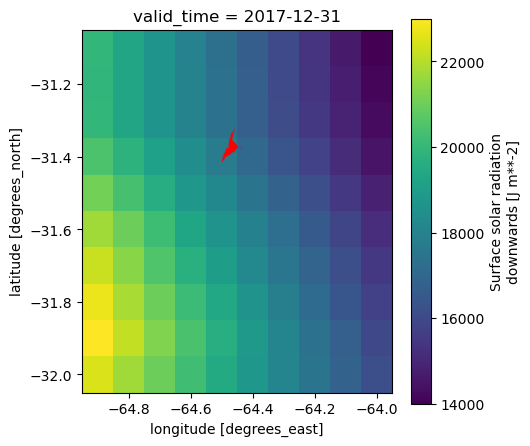

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
ds.isel(valid_time=0).ssrd.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [35]:
ds

<xarray.Dataset> Size: 29MB
Dimensions:      (valid_time: 70176, latitude: 10, longitude: 10)
Coordinates:
  * latitude     (latitude) float64 80B -32.0 -31.9 -31.8 ... -31.3 -31.2 -31.1
  * longitude    (longitude) float64 80B -64.9 -64.8 -64.7 ... -64.2 -64.1 -64.0
  * valid_time   (valid_time) datetime64[ns] 561kB 2017-12-31 ... 2026-01-01T...
    spatial_ref  int64 8B 0
Data variables:
    ssrd         (valid_time, latitude, longitude) float32 28MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-03-04T23:33 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [36]:
print("Raster x:", ds.longitude.min().item(), ds.longitude.max().item())
print("Raster y:", ds.latitude.min().item(), ds.latitude.max().item())
print("Vector bounds:", esr_vector.total_bounds)  # minx, miny, maxx, maxy

Raster x: -64.9000000000014 -64.0000000000012
Raster y: -31.99999999999935 -31.099999999999337
Vector bounds: [-64.49914798 -31.41581278 -64.43258918 -31.31939142]


In [40]:
ds = ds.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds = ds.rio.write_crs("EPSG:4326", inplace=False)

crs = ds['ssrd'].rio.crs
esr_vector = esr_vector.to_crs(crs)
ds_clip = ds.rio.clip(esr_vector.geometry, all_touched=True)

c:\Users\win10\anaconda3\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'MultiPolygon', 'coordinates': []} at index 0 will not be rasterized.
  warnings.warn(
c:\Users\win10\anaconda3\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'MultiPolygon', 'coordinates': []} at index 1 will not be rasterized.
  warnings.warn(
c:\Users\win10\anaconda3\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'MultiPolygon', 'coordinates': []} at index 2 will not be rasterized.
  warnings.warn(
c:\Users\win10\anaconda3\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'MultiPolygon', 'coordinates': []} at index 3 will not be rasterized.
  warnings.warn(
c:\Users\win10\anaconda3\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'MultiPolygon', 'coordinates': []} at index 4 will not be

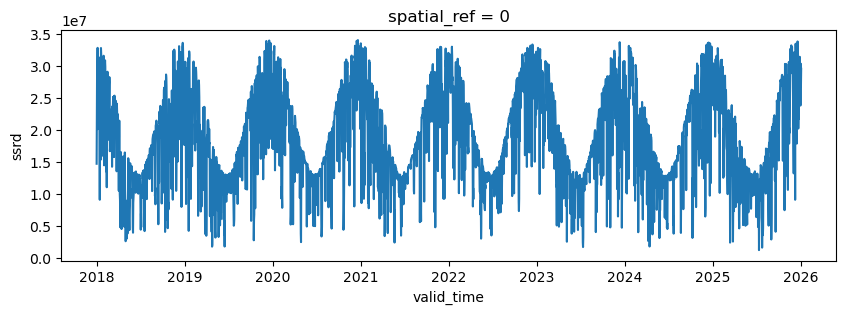

In [55]:
fig, ax = plt.subplots(figsize=(10, 3))
spatial_mean = ds_clip.mean(dim=['latitude', 'longitude'])
# daily_mean = spatial_mean.resample(time='1D').mean()  
# daily_mean = ds_clip.mean(dim=['latitude', 'longitude']).resample(time='1D').mean()
#ds_clip.mean(dim=['latitude', 'longitude']).ssrd.plot(ax=ax)#isel(valid_time=0).ssrd.plot()
# choose based on what ssrd means in your file:
'''daily_total = spatial_mean['ssrd'].resample(time='1D').sum()     # if hourly increments
# or
daily_total = spatial_mean['ssrd'].resample(time='1D').last()    # if accumulated since 00 UTC'''
spatial_mean['ssrd'].resample(valid_time='1D').sum().plot(ax=ax)

In [ ]:
print("Raster x:", ds.longitude.min().item(), ds.longitude.max().item())
print("Raster y:", ds.latitude.min().item(), ds.latitude.max().item())
print("Vector bounds:", esr_vector.total_bounds)  # minx, miny, maxx, maxy

Raster x: -64.9000000000014 -64.0000000000012
Raster y: -31.99999999999935 -31.099999999999337
Vector bounds: [-64.49914798 -31.41581278 -64.43258918 -31.31939142]


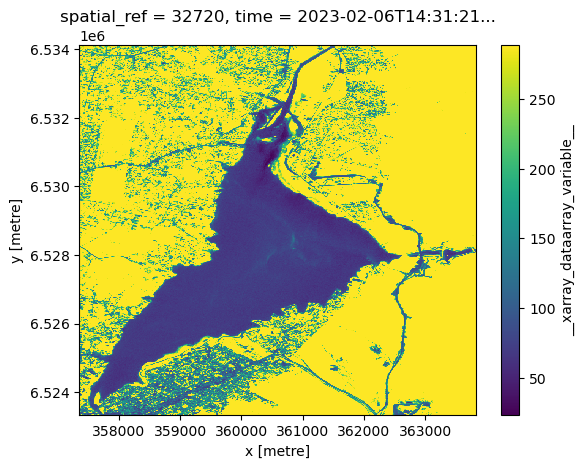

In [13]:
ds.isel(time=0)['__xarray_dataarray_variable__'].plot()

In [15]:
chla_ts = ds.mean(dim=['x', 'y'])

In [ ]:
meteo_data['dateTime'] = pd.to_datetime(meteo_data['dateTime'])

In [33]:
meteo_data.dtypes

avg_pressure                     int64
outTempMax                     float64
outTempMin                     float64
avg_outHumidity                float64
avg_windSpeed                    int64
avg_windDir                    float64
total_rain                     float64
avg_dewpoint                   float64
avg_heatindex                  float64
dateTime           datetime64[ns, UTC]
dtype: object

In [38]:
chla_vals = chla_ts['__xarray_dataarray_variable__'].values
chla_ts_time = chla_ts.time.values

In [51]:
precp_data = np.array(meteo_data['total_rain'])
temp_data = np.array(meteo_data['outTempMax'])

In [52]:
chla_vals_norm = (chla_vals-chla_vals.min())/(chla_vals.max()-chla_vals.min())
precp_data_norm = (precp_data-precp_data.min())/(precp_data.max()-precp_data.min())
temp_data_norm = (temp_data-temp_data.min())/(temp_data.max()-temp_data.min())


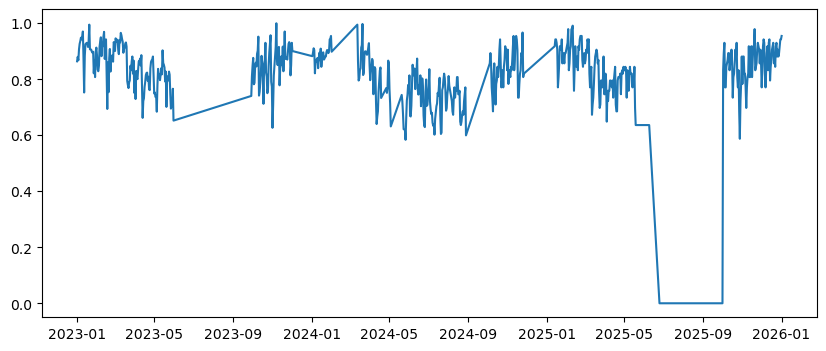

In [54]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(meteo_data['dateTime'], temp_data_norm)

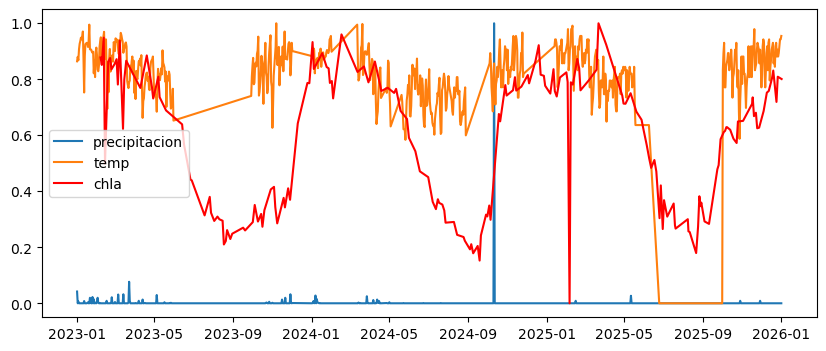

In [57]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(meteo_data['dateTime'], precp_data_norm, label='precipitacion')
ax.plot(meteo_data['dateTime'], temp_data_norm, label='temp')
ax.plot(chla_ts_time, chla_vals_norm, color='red', label='chla')

ax.legend()